Assignment 1 — Build Linear Regression From Scratch (No sklearn)
Implement Linear Regression using Gradient Descent from scratch.
Dataset
Use California Housing Dataset or Boston Housing Dataset (alternative).
Participants may download from:
Kaggle or sklearn datasets
Tasks
1. Load dataset using pandas.
2. Perform data exploration.
3. Handle:
missing values
outliers
4. Normalize features using StandardScaler logic (manual).
5. Implement Linear Regression from scratch:
initialize weights
implement cost function (MSE)
implement gradient descent
6. Train model for multiple learning rates.
7. Plot cost vs iterations.
8. Compare results with sklearn LinearRegression.
Deliverables
Participants must show:
MAE
MSE
RMSE
R²
comparison with sklearn model
Also try:
Implement Stochastic Gradient Descent (SGD) version

In [1]:
import subprocess, sys
for pkg in ['statsmodels', 'joblib']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, joblib
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing, load_diabetes
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 11})
sns.set_palette('husl')

def print_metrics(y_true, y_pred, label='Model'):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f'\n{label}')
    print(f'  MAE  = {mae:.4f}')
    print(f'  MSE  = {mse:.4f}')
    print(f'  RMSE = {rmse:.4f}')
    print(f'  R2   = {r2:.4f}')
    return dict(label=label, MAE=mae, MSE=mse, RMSE=rmse, R2=r2)

print('All libraries imported successfully!')

All libraries imported successfully!


In [2]:
housing = fetch_california_housing(as_frame=True)
df1 = housing.frame.copy()
print('Shape:', df1.shape)
df1.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print(df1.describe().T.round(2))
print(df1.isnull().sum())

               count     mean      std     min     25%      50%      75%  \
MedInc       20640.0     3.87     1.90    0.50    2.56     3.53     4.74   
HouseAge     20640.0    28.64    12.59    1.00   18.00    29.00    37.00   
AveRooms     20640.0     5.43     2.47    0.85    4.44     5.23     6.05   
AveBedrms    20640.0     1.10     0.47    0.33    1.01     1.05     1.10   
Population   20640.0  1425.48  1132.46    3.00  787.00  1166.00  1725.00   
AveOccup     20640.0     3.07    10.39    0.69    2.43     2.82     3.28   
Latitude     20640.0    35.63     2.14   32.54   33.93    34.26    37.71   
Longitude    20640.0  -119.57     2.00 -124.35 -121.80  -118.49  -118.01   
MedHouseVal  20640.0     2.07     1.15    0.15    1.20     1.80     2.65   

                  max  
MedInc          15.00  
HouseAge        52.00  
AveRooms       141.91  
AveBedrms       34.07  
Population   35682.00  
AveOccup      1243.33  
Latitude        41.95  
Longitude     -114.31  
MedHouseVal      5.00  

In [5]:
df1.fillna(df1.median(numeric_only=True), inplace=True)

Q1, Q3 = df1['MedHouseVal'].quantile([0.25, 0.75])
IQR = Q3 - Q1
df1 = df1[(df1['MedHouseVal'] >= Q1 - 1.5*IQR) & (df1['MedHouseVal'] <= Q3 + 1.5*IQR)]
print(f'Shape after outlier removal: {df1.shape}')

Shape after outlier removal: (19569, 9)


In [6]:
X1 = df1.drop('MedHouseVal', axis=1).values
y1 = df1['MedHouseVal'].values

X1_mean = X1.mean(axis=0)
X1_std  = X1.std(axis=0)
X1_norm = (X1 - X1_mean) / X1_std

split = int(0.8 * len(X1_norm))
X_tr, X_te = X1_norm[:split], X1_norm[split:]
y_tr, y_te = y1[:split], y1[split:]

X_tr_b = np.c_[np.ones(len(X_tr)), X_tr]
X_te_b = np.c_[np.ones(len(X_te)), X_te]
print('Training set:', X_tr_b.shape)

Training set: (15655, 9)


In [7]:
class LinearRegressionScratch:
    def __init__(self, lr=0.01, n_iter=1000):
        self.lr, self.n_iter = lr, n_iter
        self.weights = None
        self.cost_history = []

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.cost_history = []
        for _ in range(self.n_iter):
            y_hat  = X @ self.weights
            error  = y_hat - y
            grad   = (2/m) * X.T @ error
            self.weights -= self.lr * grad
            self.cost_history.append(np.mean((y - y_hat)**2))
        return self

    def predict(self, X):
        return X @ self.weights


class SGDLinearRegression:
    def __init__(self, lr=0.01, n_iter=50, batch_size=32):
        self.lr, self.n_iter, self.batch_size = lr, n_iter, batch_size
        self.weights = None
        self.cost_history = []

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.cost_history = []
        for _ in range(self.n_iter):
            idx = np.random.permutation(m)
            X_sh, y_sh = X[idx], y[idx]
            for i in range(0, m, self.batch_size):
                xb = X_sh[i:i+self.batch_size]
                yb = y_sh[i:i+self.batch_size]
                grad = (2/len(xb)) * xb.T @ (xb @ self.weights - yb)
                self.weights -= self.lr * grad
            self.cost_history.append(np.mean((X @ self.weights - y)**2))
        return self

    def predict(self, X):
        return X @ self.weights

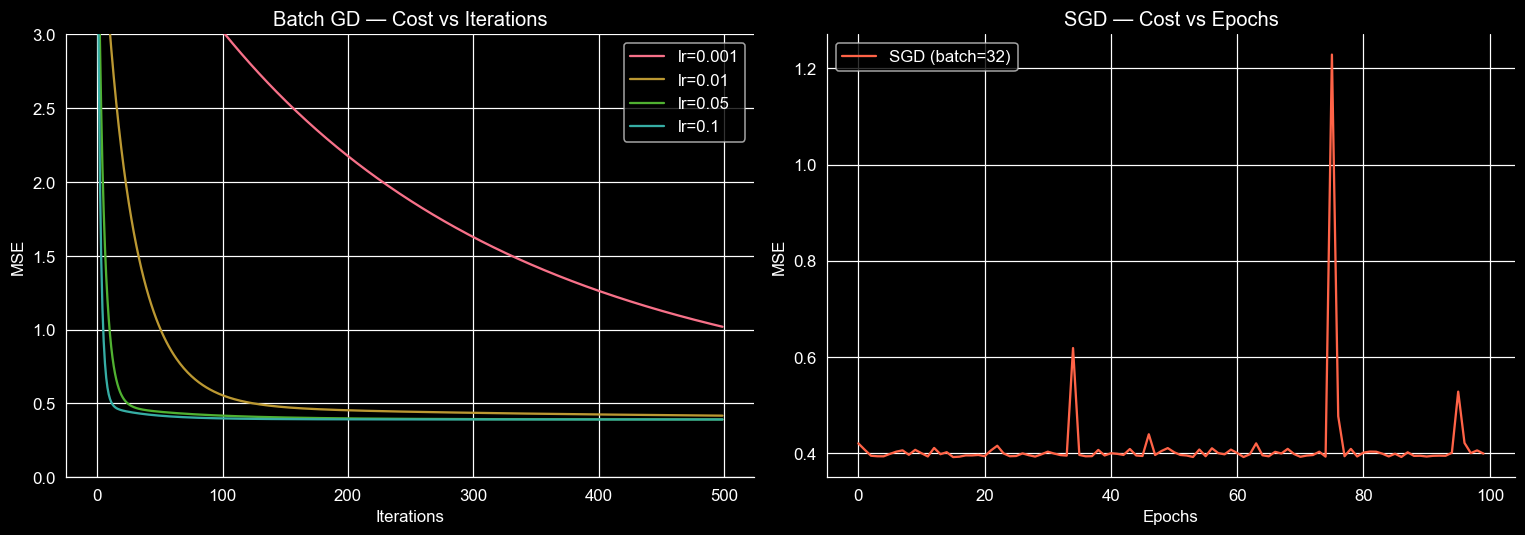

In [8]:

learning_rates = [0.001, 0.01, 0.05, 0.1]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_scratch = {}
for lr in learning_rates:
    m = LinearRegressionScratch(lr=lr, n_iter=500)
    m.fit(X_tr_b, y_tr)
    models_scratch[lr] = m
    axes[0].plot(m.cost_history, label=f'lr={lr}')

axes[0].set_title('Batch GD — Cost vs Iterations')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].set_ylim(0, 3)

sgd = SGDLinearRegression(lr=0.01, n_iter=100, batch_size=32)
sgd.fit(X_tr_b, y_tr)
axes[1].plot(sgd.cost_history, color='tomato', label='SGD (batch=32)')
axes[1].set_title('SGD — Cost vs Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('MSE')
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
y_pred_scratch = models_scratch[0.05].predict(X_te_b)
y_pred_sgd     = sgd.predict(X_te_b)

sk_lr = LinearRegression().fit(X_tr, y_tr)
y_pred_sk = sk_lr.predict(X_te)

r1a = print_metrics(y_te, y_pred_scratch, 'Scratch GD  (lr=0.05)')
r1b = print_metrics(y_te, y_pred_sgd,     'Scratch SGD (lr=0.01)')
r1c = print_metrics(y_te, y_pred_sk,      'sklearn LinearRegression')

print(pd.DataFrame([r1a, r1b, r1c]).set_index('label').round(4))


Scratch GD  (lr=0.05)
  MAE  = 0.4645
  MSE  = 0.3930
  RMSE = 0.6269
  R2   = 0.6162

Scratch SGD (lr=0.01)
  MAE  = 0.4637
  MSE  = 0.3822
  RMSE = 0.6182
  R2   = 0.6268

sklearn LinearRegression
  MAE  = 0.4642
  MSE  = 0.3883
  RMSE = 0.6231
  R2   = 0.6209
                             MAE     MSE    RMSE      R2
label                                                   
Scratch GD  (lr=0.05)     0.4645  0.3930  0.6269  0.6162
Scratch SGD (lr=0.01)     0.4637  0.3822  0.6182  0.6268
sklearn LinearRegression  0.4642  0.3883  0.6231  0.6209


In [12]:
df1.isna().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

<Axes: >

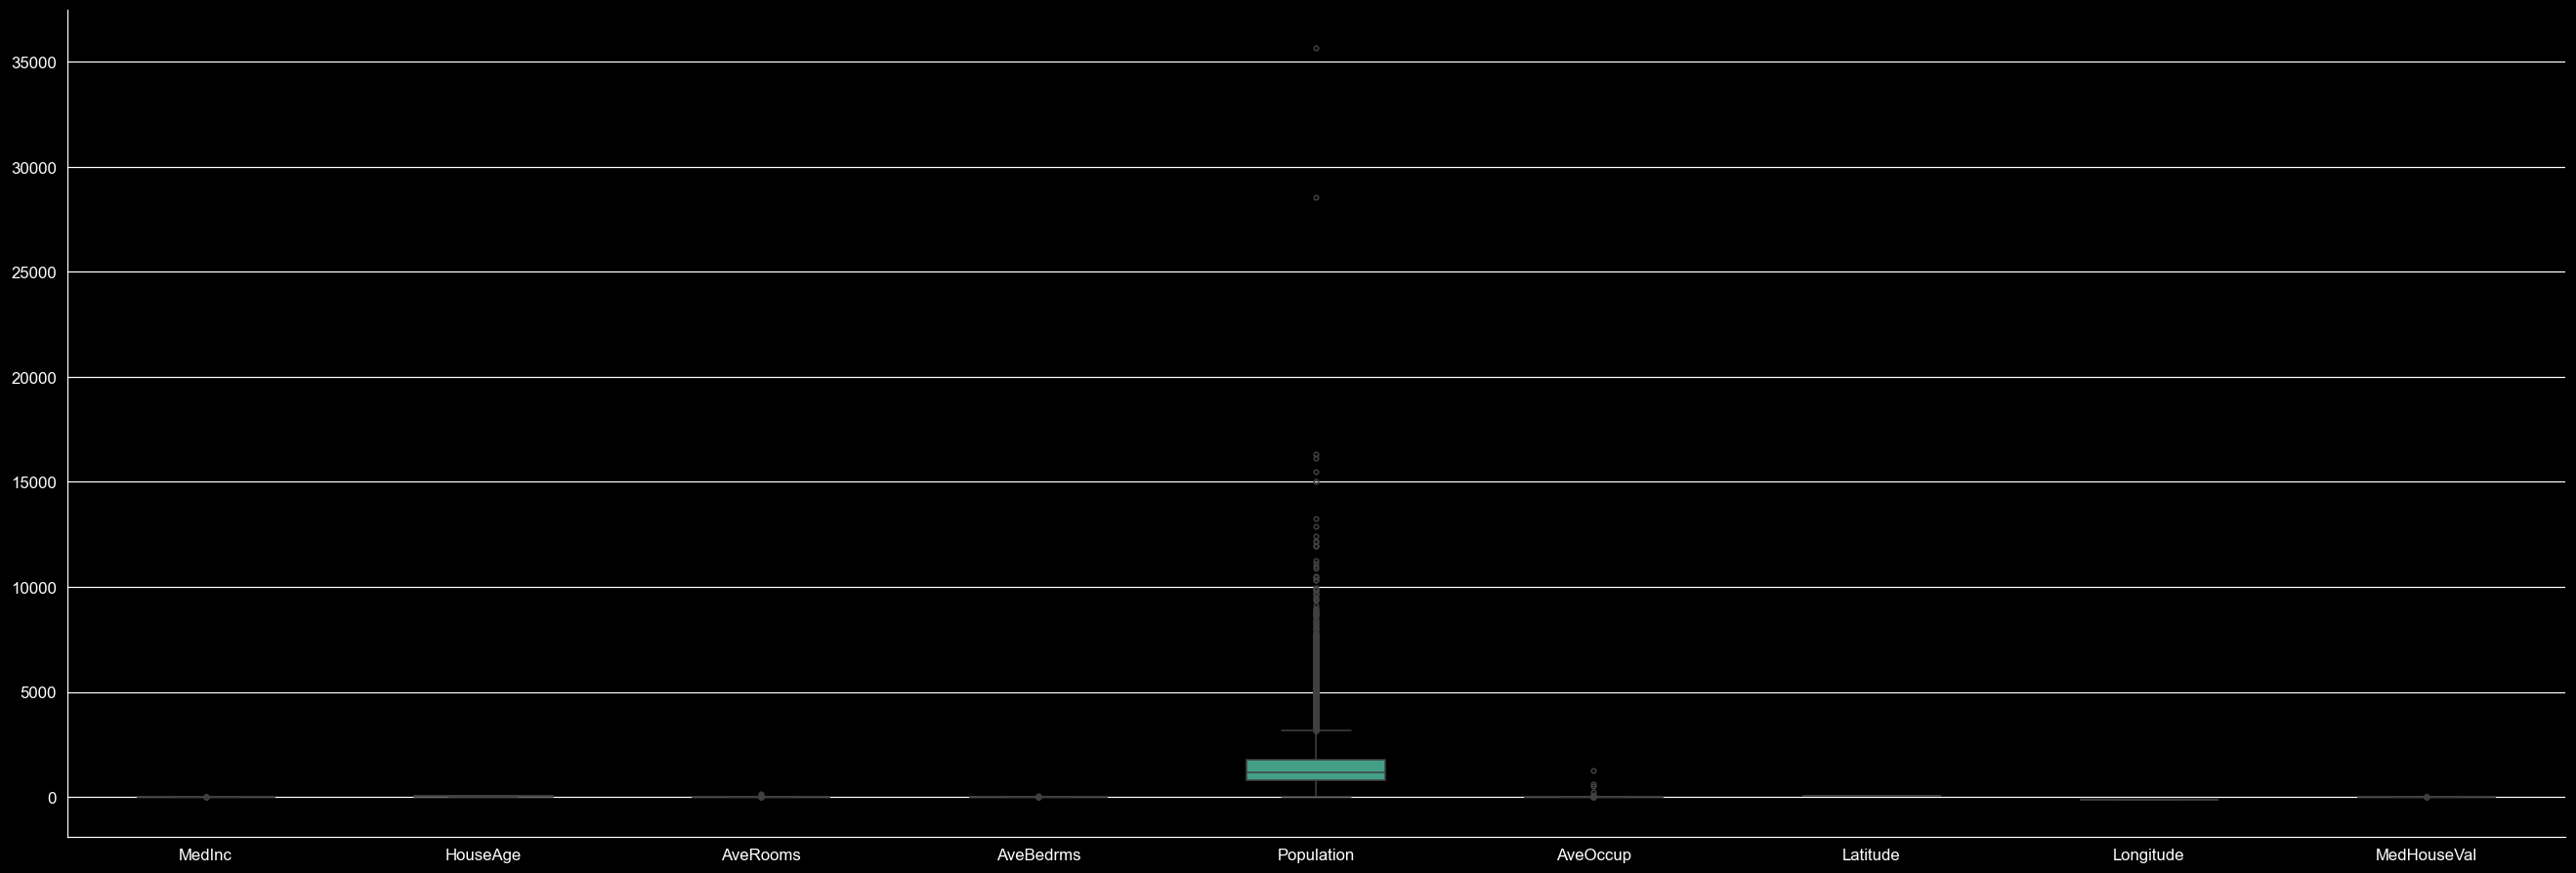

In [14]:
fig,ax=plt.subplots(figsize=(30,10),facecolor='black')
sns.boxplot(data=df1, width=0.5, ax=ax,fliersize=3)

In [16]:
df1

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
